Question 1:Which sensors change the most throughout the dataset?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
columns_names=["engine_id","cycle"]+[f"setting_{i}" for i in range(1,4)]+[f"sensor_{i}" for i in range(1,22)]

df=pd.read_csv("../Data/raw/train_FD001.txt",sep=r"\s+",header=None)

df.columns=columns_names

In [3]:
sensor_columns=[f"sensor_{i}" for i in range(1,22)]

sensor_data=df[sensor_columns]

In [4]:
sensor_std= sensor_data.std()

sensor_std

    

sensor_1     0.000000e+00
sensor_2     5.000533e-01
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_7     8.850923e-01
sensor_8     7.098548e-02
sensor_9     2.208288e+01
sensor_10    0.000000e+00
sensor_11    2.670874e-01
sensor_12    7.375534e-01
sensor_13    7.191892e-02
sensor_14    1.907618e+01
sensor_15    3.750504e-02
sensor_16    3.469531e-18
sensor_17    1.548763e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_20    1.807464e-01
sensor_21    1.082509e-01
dtype: float64

In [16]:
[df["engine_id"]== 1]

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [5]:
sensor_std=sensor_std.sort_values(ascending=False)

sensor_std

sensor_9     2.208288e+01
sensor_14    1.907618e+01
sensor_4     9.000605e+00
sensor_3     6.131150e+00
sensor_17    1.548763e+00
sensor_7     8.850923e-01
sensor_12    7.375534e-01
sensor_2     5.000533e-01
sensor_11    2.670874e-01
sensor_20    1.807464e-01
sensor_21    1.082509e-01
sensor_13    7.191892e-02
sensor_8     7.098548e-02
sensor_15    3.750504e-02
sensor_6     1.388985e-03
sensor_5     5.329200e-15
sensor_16    3.469531e-18
sensor_10    0.000000e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_1     0.000000e+00
dtype: float64

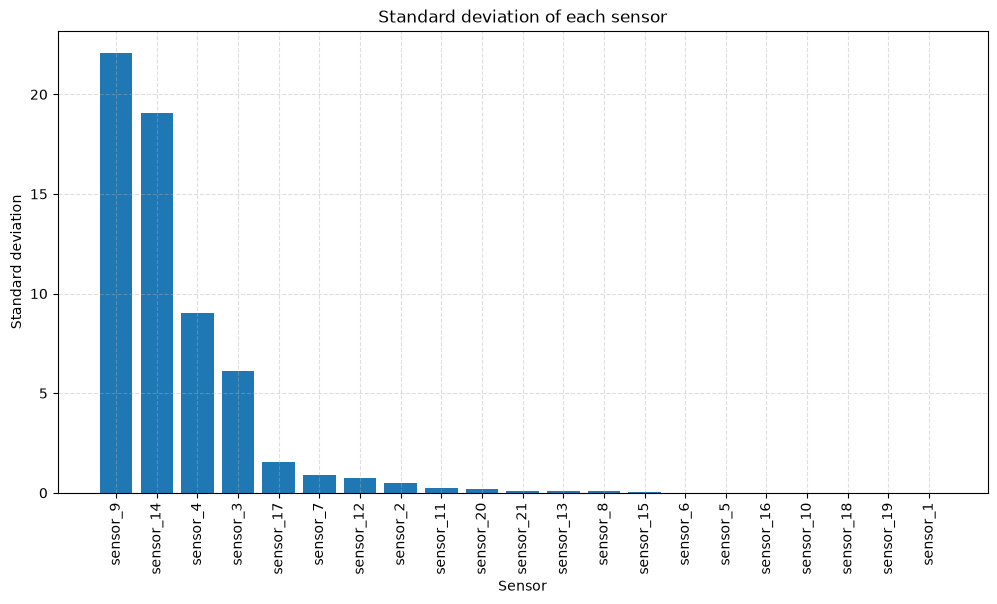

In [6]:
plt.figure(figsize=(12,6))

plt.bar(sensor_std.index,sensor_std.values)

plt.xticks(rotation=90)

plt.title("Standard deviation of each sensor")
plt.xlabel("Sensor")
plt.ylabel("Standard deviation")
plt.grid(True, linestyle='--',alpha=0.4)

plt.savefig('../figures/05_Standard_deviation_of_each_Senosor')

plt.show()

Observation: Sensor 1,19,18,10,16,5,6 show extremely little or no standard deviation.
This indicates that these sensors show little or no change throughout the data set.
Because they show little variation ,Sensor 1,19,18,10,16,5,6 are unlikely to provide information for monitoring engine degradation.

Question 2: Which sensors behave similarly?

In [7]:
correlation = sensor_data.corr()


<function matplotlib.pyplot.show(close=None, block=None)>

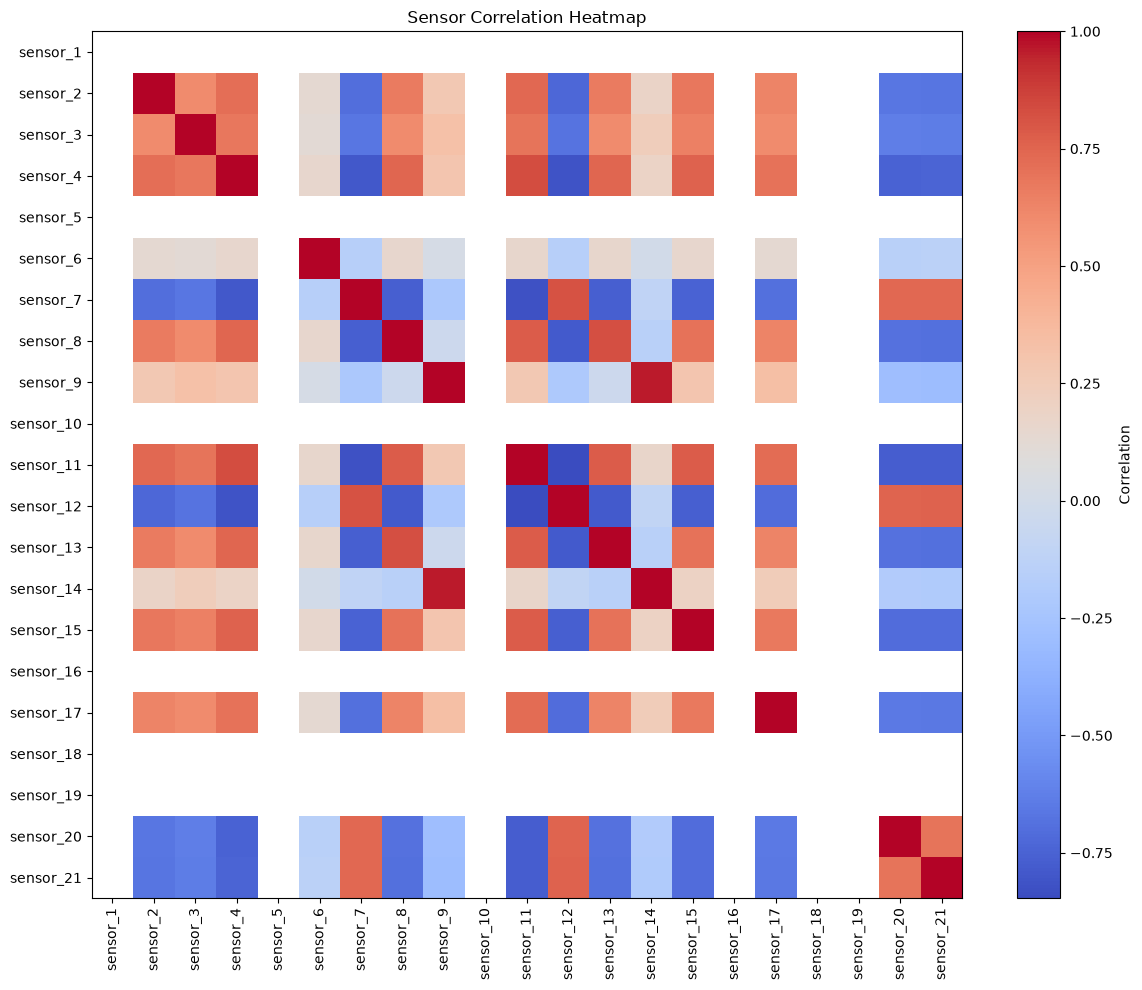

In [8]:
plt.figure(figsize=(12,10))

plt.imshow(correlation,cmap="coolwarm",aspect="auto")

plt.colorbar(label="Correlation")
plt.xticks(range(len(sensor_columns)),sensor_columns,rotation=90)
plt.yticks(range(len(sensor_columns)),sensor_columns)

plt.title("Sensor Correlation Heatmap")

plt.savefig('../figures/06_Sensor Correlation Heatmap')

plt.tight_layout()

plt.show

Observation: Sensor 9 and Sensor 14 appear to be highly correlated. Sensor 1,5,10,16,18,19 appear to be independent.

In [9]:
selected_engines= [1,9,20,21,99]

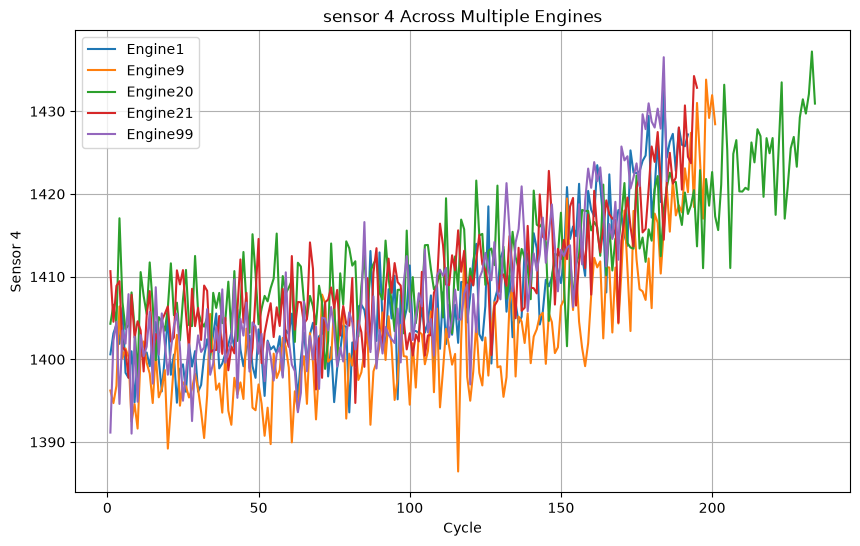

In [10]:
plt.figure(figsize=(10,6))

for engine in selected_engines:
    engine_data=df[df["engine_id"]==engine]
    
    plt.plot(engine_data["cycle"],engine_data["sensor_4"],label=f"Engine{engine}")

plt.title("sensor 4 Across Multiple Engines")

plt.xlabel("Cycle")

plt.ylabel("Sensor 4")
plt.legend()
plt.grid(True)
plt.show()

Observation:Sensor 4 remains relatively stable during the early operating cycles but begins to increase after approximately 100 cycles. The consistent upward trend observed across multiple engines suggests that Sensor 4 may be a strong candidate for monitoring engine degradation.

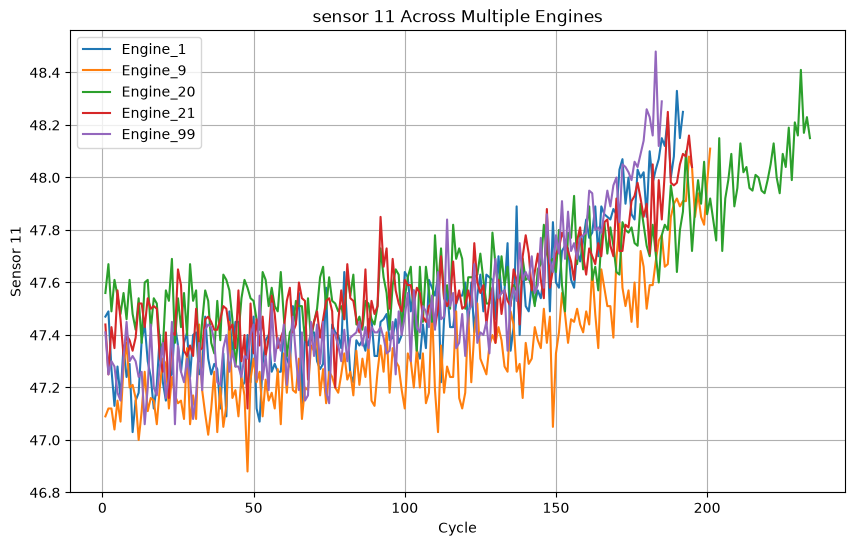

In [11]:
plt.figure(figsize=(10,6))

for engine in selected_engines:
    engine_data=df[df["engine_id"]==engine]
    plt.plot(engine_data["cycle"],engine_data["sensor_11"],label=f"Engine_{engine}")

plt.title("sensor 11 Across Multiple Engines")

plt.xlabel("Cycle")

plt.ylabel("Sensor 11")
plt.legend()
plt.grid(True)
plt.show()
    
    

Observation: Sensor 11 remains relatively stable during approximately the first 110 operating cycles before showing a moderate upward trend. This behavior suggests that Sensor 11 may become more sensitive as the engine approaches the later stages of its operating life.

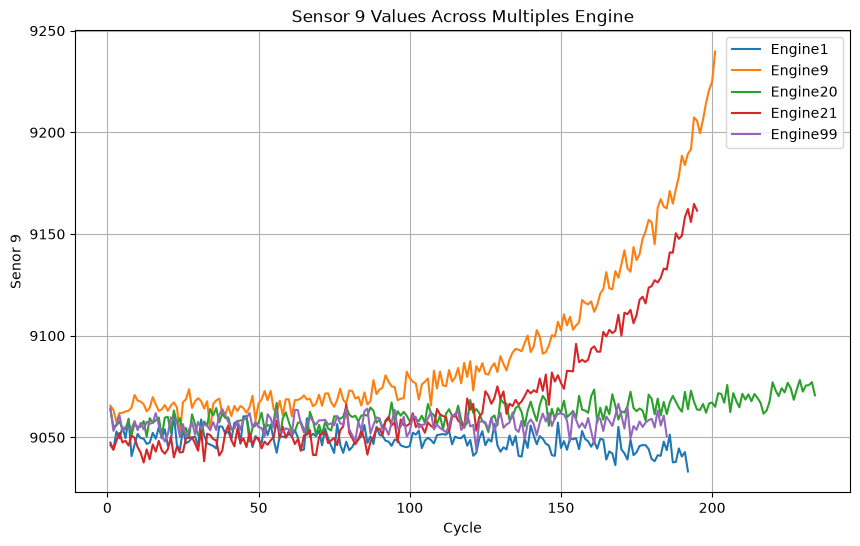

In [12]:
plt.figure(figsize=(10,6))

for engine in selected_engines:
    engine_data= df[df["engine_id"]==engine]
    
    plt.plot(engine_data["cycle"],engine_data["sensor_9"],label=f"Engine{engine}")

plt.title("Sensor 9 Values Across Multiples Engine")
plt.xlabel('Cycle')
plt.ylabel('Senor 9')
plt.legend()
plt.grid(True)

plt.show()

Observation: Sensor 9 displays inconsistent behavior across the selected engines. Some engines exhibit little change, whereas others experience noticeable increases after approximately 100 operating cycles. This variability suggests that further investigation is needed before determining its usefulness for monitoring engine health.

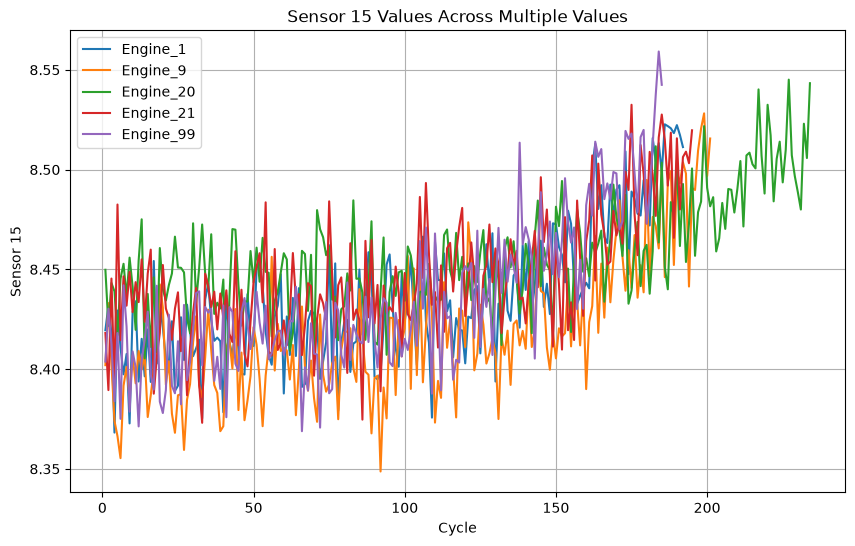

In [13]:
plt.figure(figsize=(10,6))

for engine in selected_engines:
    engine_data= df[df['engine_id']==engine]
    
    plt.plot(engine_data["cycle"],engine_data["sensor_15"],label=f"Engine_{engine}")
    
plt.title("Sensor 15 Values Across Multiple Values")
plt.xlabel("Cycle")
plt.ylabel("Sensor 15")
plt.grid(True)
plt.legend()

plt.show()

Observation: Sensor 15 remains relatively stable during approximately the first 150 operating cycles before exhibiting a gradual increase. Although the increase is small, the consistent trend across the selected engines suggests that Sensor 15 may contain useful information about engine degradation.

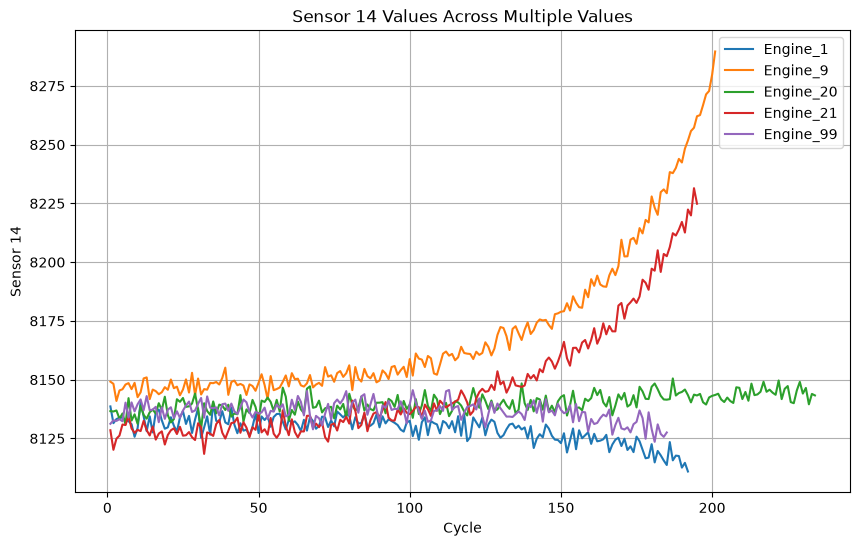

In [14]:
plt.figure(figsize=(10,6))

for engine in selected_engines:
    engine_data= df[df['engine_id']==engine]
    
    plt.plot(engine_data["cycle"],engine_data["sensor_14"],label=f"Engine_{engine}")
    
plt.title("Sensor 14 Values Across Multiple Values")
plt.xlabel("Cycle")
plt.ylabel("Sensor 14")
plt.grid(True)
plt.legend()

plt.show()

Observation: Sensor 14 exhibits different behaviors across the selected engines. For Engines 1, 20, and 99, the sensor remains relatively constant throughout the operating life, whereas Engines 9 and 21 show an increase after approximately 100 operating cycles. Because this behavior is inconsistent across engines, additional analysis is required before determining whether Sensor 14 is a reliable indicator of engine degradation.

|Sensor|Standard Deviation|Trend Across Engines|Reccomendation|Notes|
|------|------------------|--------------------|--------------|-----|
|Sensor 4|9.00|Increasing|Investigate|Strong upward after-100 cycles.|
|Sensor 11|0.27|Increasing|Investigate|Moderate Upward Trend after-110 cycles.|
|Sensor 9|22.08|Mixed|Investigate Further|High Variability, but inconsistent across engines.|
|Sensor 15|0.038|Increasing|Investigate Carefully|Small increase despite very low variabilty.|
|Sensor 14|19.08|Mixed|Investigate Further|Behaviour differs between engines.|
